# PART A: Image Classification (CNN).

## 1. Imports

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import random
from PIL import Image

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Directory

In [6]:
test_dir = "/content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Test"
train_dir = "/content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Train"

## Understanding Data & Visualization


### Classes

In [7]:
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 5 classes: ['Banana', 'Cherry', 'Grape', 'Mango', 'Peach']


### Checking Corrupted Images.

In [8]:
corrupted = []

for cls in class_names:
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

Removed corrupted image: /content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Train/Banana/r2_73_100.jpg
Removed corrupted image: /content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Train/Banana/r_14_100.jpg
Removed corrupted image: /content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Train/Banana/r_162_100.jpg
Removed corrupted image: /content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Train/Banana/r_95_100.jpg
Removed corrupted image: /content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Train/Banana/136_100.jpg
Removed corrupted image: /content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Train/Banana/22_100(1).jpg
Removed corrupted image: /content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Train/Banana/r_227_100.jpg
Removed corrupted image: /content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Train/Cherry/r_217_100.jpg
Removed corrupted image: /content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Train/Cherry/r_202_100.jpg
Removed corrupted image: /content/drive/MyDrive/AI

### Class Count Balance

In [9]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
  print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
Banana                              1422
Cherry                              1222
Grape                               1468
Mango                                908
Peach                               1222


### Select Random Images for Visualization

In [10]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)

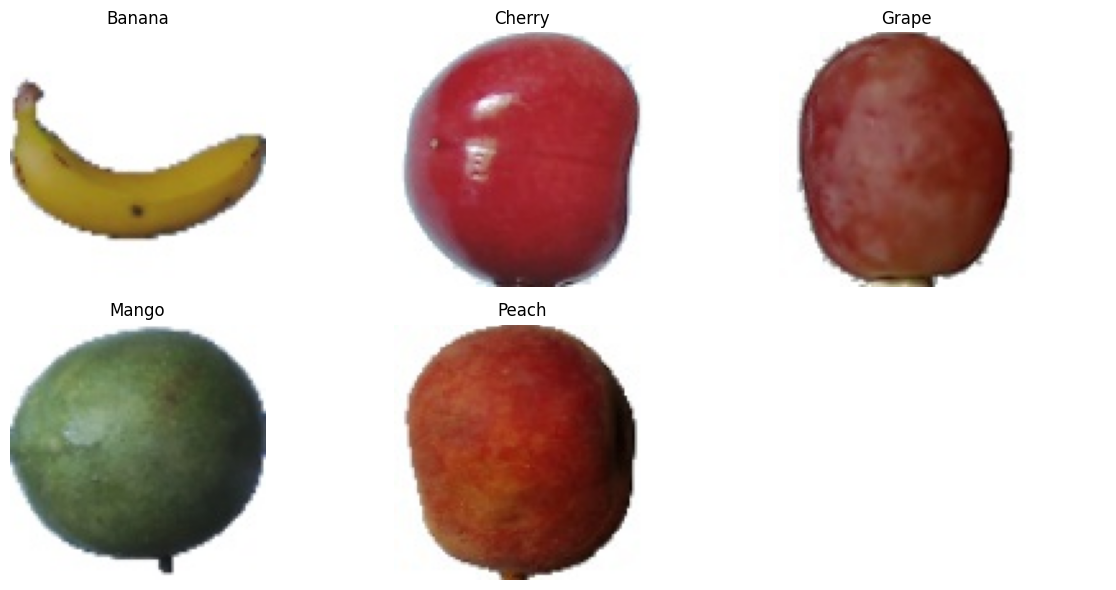

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

## Data Preprocessing and Generation

In [12]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [13]:
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 6242 files belonging to 5 classes.
Using 4994 files for training.
Found 6242 files belonging to 5 classes.
Using 1248 files for validation.
Found 5 files belonging to 5 classes.


In [14]:
print(f"Contents of {test_dir}:")
files_in_test_dir = os.listdir(test_dir)
if files_in_test_dir:
    print(files_in_test_dir)
else:
    print("The directory is empty or does not exist.")

Contents of /content/drive/MyDrive/AIML/Assessment/Part-2/Dataset/Test:
['Banana', 'Cherry', 'Grape', 'Peach', 'Mango']


In [15]:
data_augmentation_layers = [
     layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
]

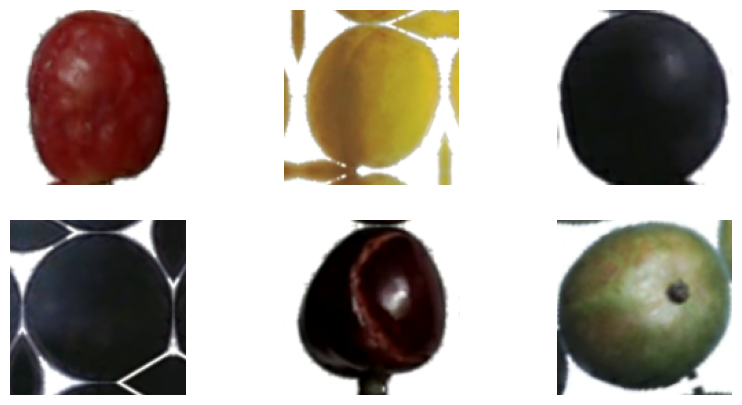

In [16]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,5))
    for i in range(6):
        ax = plt.subplot(2,3,i+1)
        augmented = images[i]
        for layer in data_augmentation_layers:
            augmented = layer(augmented)
        plt.imshow(augmented.numpy().astype("uint8"))
        plt.axis("off")

In [17]:
normalization_layer = layers.Rescaling(1./255)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

num_classes = len(train_ds.class_names)

baseline_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    *data_augmentation_layers,

    normalization_layer,

    # CNN Layers
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])



In [19]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # IMPORTANT CHANGE
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,315,141 (12.65 MB)

 Trainable params: 3,315,141 (12.65 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 162ms/step - accuracy: 0.9039 - loss: 0.2761 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 157ms/step - accuracy: 0.9904 - loss: 0.0335 - val_accuracy: 0.9992 - val_loss: 0.0019
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 157ms/step - accuracy: 0.9936 - loss: 0.0239 - val_accuracy: 1.0000 - val_loss: 1.5335e-04
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - accuracy: 0.9886 - loss: 0.0376 - val_accuracy: 1.0000 - val_loss: 0.0115
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - accuracy: 0.9988 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 4.3439e-05
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 142ms/step - accuracy: 0.9998 - loss: 5.8116e-04 - val_accuracy: 1.0000 - val_loss: 4.3991e-05
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - accuracy: 0.9902 - loss: 0.0346 - val_accuracy: 0.9960 - val_loss: 0.0245
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 143ms/step - accuracy: 

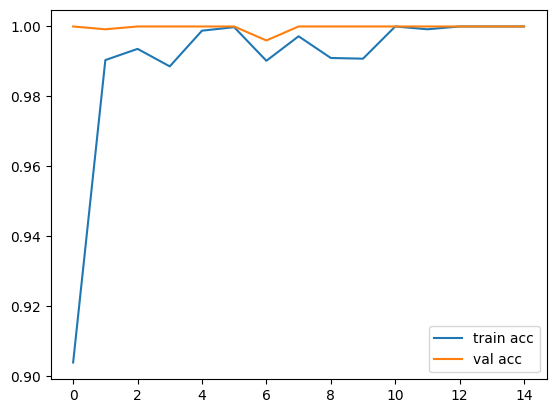

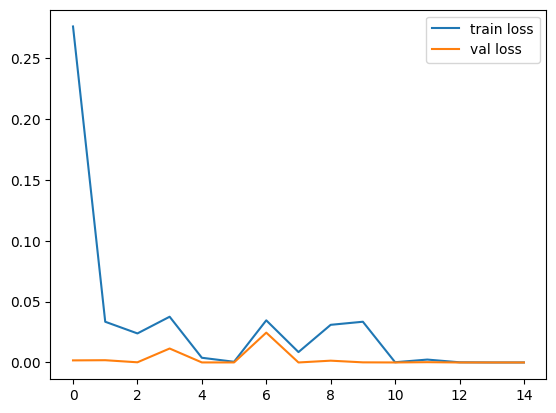

In [21]:
plt.plot(history_baseline.history['accuracy'], label='train acc')
plt.plot(history_baseline.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history_baseline.history['loss'], label='train loss')
plt.plot(history_baseline.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = baseline_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

class_names = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00         1
      Cherry       1.00      1.00      1.00         1
       Grape       1.00      1.00      1.00         1
       Mango       1.00      1.00      1.00         1
       Peach       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



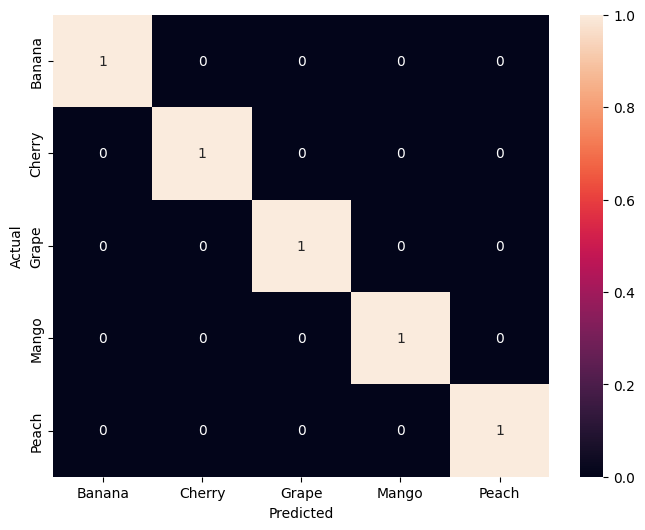

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Deeper Model

In [24]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(train_ds.class_names)

deep_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # ✅ Data Augmentation (same as before)
    *data_augmentation_layers,

    # ✅ Normalize
    layers.Rescaling(1./255),

    # 🔹 Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔹 Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔹 Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # 🔹 Extra Depth (important for assignment)
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # 🔹 Fully Connected
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,978,213 (11.36 MB)

 Trainable params: 2,976,741 (11.36 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [26]:
history_deep = deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 168ms/step - accuracy: 0.8530 - loss: 0.4269 - val_accuracy: 0.2508 - val_loss: 6.9809
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 164ms/step - accuracy: 0.9549 - loss: 0.1453 - val_accuracy: 0.0938 - val_loss: 7.6267
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 194ms/step - accuracy: 0.9738 - loss: 0.0924 - val_accuracy: 0.5280 - val_loss: 1.5616
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 159ms/step - accuracy: 0.9413 - loss: 0.1933 - val_accuracy: 0.9744 - val_loss: 0.0791
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - accuracy: 0.9515 - loss: 0.1564 - val_accuracy: 0.9880 - val_loss: 0.0337
Epoch 6/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.9790 - loss: 0.0704 - val_accuracy: 0.9607 - val_loss: 0.0844
Epoch 7/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 154ms/step - accuracy: 0.9896 - loss: 0.0348 - val_accuracy: 0.8870 - val_loss: 0.3482
Epoch 8/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.9746 - loss: 0

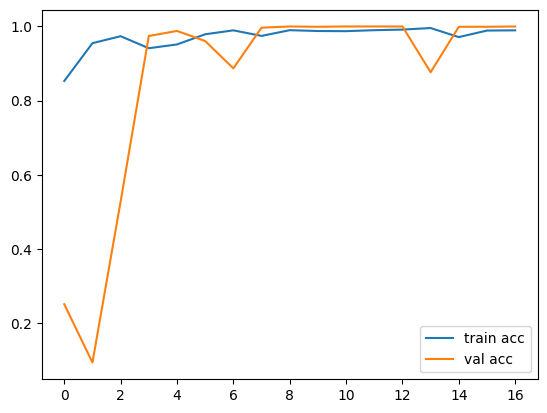

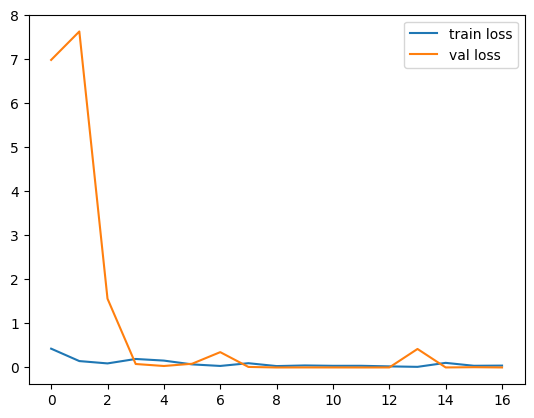

In [27]:
plt.plot(history_deep.history['accuracy'], label='train acc')
plt.plot(history_deep.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history_deep.history['loss'], label='train loss')
plt.plot(history_deep.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [28]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = deep_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

class_names = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00         1
      Cherry       1.00      1.00      1.00         1
       Grape       1.00      1.00      1.00         1
       Mango       1.00      1.00      1.00         1
       Peach       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



SGD

In [29]:
from tensorflow.keras.optimizers import SGD

deep_model_sgd = keras.models.clone_model(deep_model)

deep_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deep_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 153ms/step - accuracy: 0.7269 - loss: 0.7694 - val_accuracy: 0.6867 - val_loss: 1.3401
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 161ms/step - accuracy: 0.8648 - loss: 0.3806 - val_accuracy: 0.4415 - val_loss: 5.3081
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 156ms/step - accuracy: 0.9299 - loss: 0.2026 - val_accuracy: 0.3141 - val_loss: 3.7737
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 159ms/step - accuracy: 0.9553 - loss: 0.1337 - val_accuracy: 0.3093 - val_loss: 5.2329
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - accuracy: 0.9642 - loss: 0.1173 - val_accuracy: 0.5144 - val_loss: 2.9562


# Part B: Fine Tuning

In [30]:
IMG_SIZE = 224

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    shuffle=False
)

Found 6242 files belonging to 5 classes.
Using 4994 files for training.
Found 6242 files belonging to 5 classes.
Using 1248 files for validation.
Found 5 files belonging to 5 classes.


In [31]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
]

In [32]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,   # ❗ Remove original classifier
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [33]:
base_model.trainable = False

In [34]:
num_classes = len(train_ds.class_names)

model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    *data_augmentation_layers,

    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [35]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,717 (9.26 MB)

 Trainable params: 167,173 (653.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [36]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 212ms/step - accuracy: 0.9656 - loss: 0.0989 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 168ms/step - accuracy: 0.9950 - loss: 0.0133 - val_accuracy: 1.0000 - val_loss: 9.7450e-04
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 163ms/step - accuracy: 0.9956 - loss: 0.0134 - val_accuracy: 1.0000 - val_loss: 6.0095e-04
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - accuracy: 0.9978 - loss: 0.0098 - val_accuracy: 1.0000 - val_loss: 8.6945e-05
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step - accuracy: 0.9980 - loss: 0.0069 - val_accuracy: 1.0000 - val_loss: 2.8284e-04
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 196ms/step - accuracy: 0.9976 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 6.0508e-05
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step - accuracy: 0.9966 - loss: 0.0111 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 157ms/step - accura

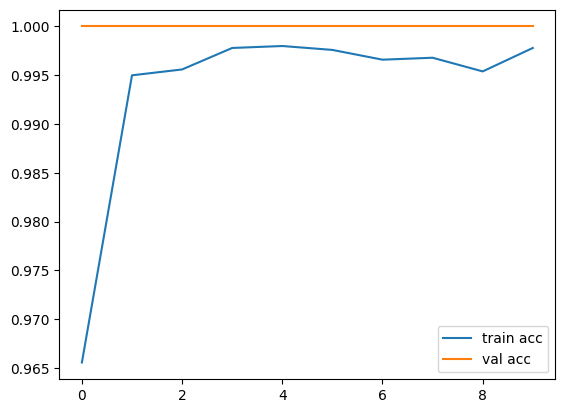

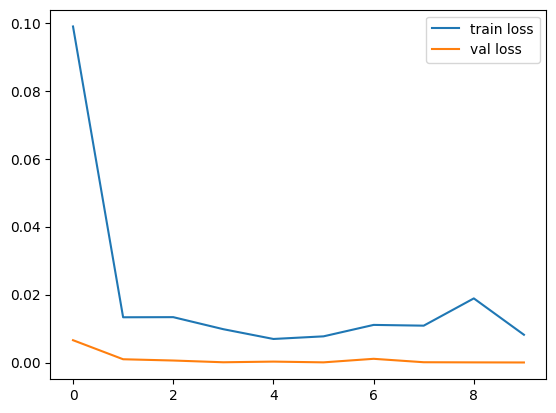

In [37]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [38]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

class_names = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00         1
      Cherry       1.00      1.00      1.00         1
       Grape       1.00      1.00      1.00         1
       Mango       1.00      1.00      1.00         1
       Peach       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [39]:
base_model.trainable = True

# Freeze lower layers, train only top layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [40]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # ⚠️ smaller LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 193ms/step - accuracy: 0.9740 - loss: 0.1093 - val_accuracy: 0.9984 - val_loss: 0.0057
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 182ms/step - accuracy: 0.9880 - loss: 0.0408 - val_accuracy: 0.9992 - val_loss: 0.0042
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 182ms/step - accuracy: 0.9920 - loss: 0.0242 - val_accuracy: 0.9992 - val_loss: 0.0024
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 177ms/step - accuracy: 0.9928 - loss: 0.0271 - val_accuracy: 1.0000 - val_loss: 4.5334e-04
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy: 0.9948 - loss: 0.0166 - val_accuracy: 1.0000 - val_loss: 8.4822e-05
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9956 - loss: 0.0154 - val_accuracy: 1.0000 - val_loss: 3.3525e-05
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 179ms/step - accuracy: 0.9962 - loss: 0.0131 - val_accuracy: 1.0000 - val_loss: 1.5478e-05
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 180ms/step - accuracy: 

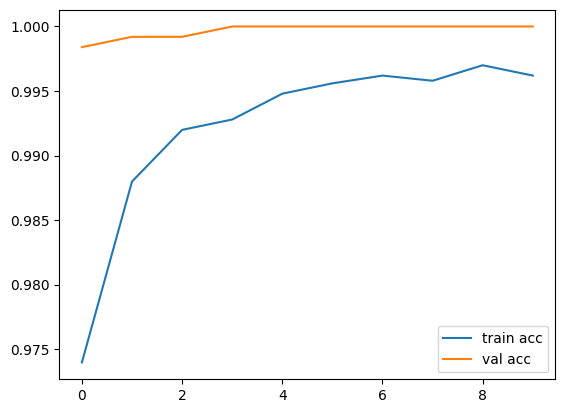

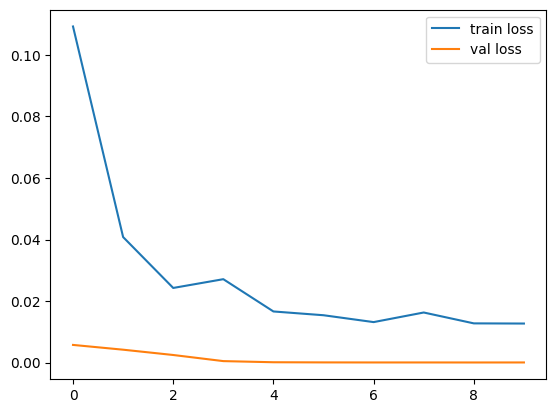

In [42]:
plt.plot(history_fine.history['accuracy'], label='train acc')
plt.plot(history_fine.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history_fine.history['loss'], label='train loss')
plt.plot(history_fine.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [43]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

class_names = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00         1
      Cherry       1.00      1.00      1.00         1
       Grape       1.00      1.00      1.00         1
       Mango       1.00      1.00      1.00         1
       Peach       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [44]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 1.0
